# Deutsch's Algorithm — Measurement-Based Verification
**Notebook:** Deutsch1 — full circuit with measurement, AerSimulator execution

# Standard Qiskit imports
import qiskit as qk
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector        # exact statevector simulation (no noise)
from qiskit.visualization import plot_bloch_multivector  # Bloch sphere visualisation
from math import pi

In [1]:
import qiskit as qk
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi

### Consider the Deusch problem with q Qubit $f(x) \rightarrow 0 \textrm{ or } 1 \textrm{ , where } x \textrm{ is } 0 \textrm{ or } 1$. Define 4 oracles :

# Oracle 1 — constant f(0)=f(1)=0
# An empty 2-qubit circuit: no gates are applied, so the ancilla is never flipped.
# Phase kickback produces no relative phase change → input qubit remains unaffected.
oracle1 = qk.QuantumCircuit(2, name='oracle1')
oracle1.draw()

In [2]:
oracle1=qk.QuantumCircuit(2, name='oracle1')
oracle1.draw()

q_0: 
     
q_1:

# Oracle 2 — balanced f(0)=0, f(1)=1
# CNOT (control=q0, target=q1): flips ancilla only when input qubit is |1⟩.
# Phase kickback with ancilla in |−⟩: a flip on |−⟩ introduces a −1 phase,
# so the relative phase between |0⟩ and |1⟩ on q0 is flipped → balanced encoding.
oracle2 = qk.QuantumCircuit(2, name='oracle2')
oracle2.cx(0, 1)   # CNOT: control=q0 (input), target=q1 (ancilla)
oracle2.draw()

In [3]:
oracle2=qk.QuantumCircuit(2, name='oracle2')
oracle2.cx(0,1)
oracle2.draw()

q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘

# Oracle 3 — balanced f(0)=1, f(1)=0  (complement of oracle2)
# CNOT flips ancilla when input=|1⟩; subsequent X on ancilla inverts unconditionally.
# Combined: ancilla is flipped when input=|0⟩ and left alone when input=|1⟩.
# This is the complemented balanced function; phase kickback still marks it as balanced.
oracle3 = qk.QuantumCircuit(2, name='oracle3')
oracle3.cx(0, 1)   # CNOT: flip ancilla if input is |1⟩
oracle3.x(1)       # X on ancilla: invert to make the flip condition input=|0⟩
oracle3.draw()

In [4]:
oracle3=qk.QuantumCircuit(2, name='oracle3')
oracle3.cx(0,1)
oracle3.x(1)
oracle3.draw()

q_0: ──■───────
     ┌─┴─┐┌───┐
q_1: ┤ X ├┤ X ├
     └───┘└───┘

# Oracle 4 — constant f(0)=f(1)=1
# X gate on ancilla q1 only (no dependence on input qubit q0).
# The ancilla flip is unconditional: both input states trigger the same phase,
# resulting in a global (unobservable) phase — input qubit is left unchanged.
oracle4 = qk.QuantumCircuit(2, name='oracle4')
oracle4.x(1)   # X on ancilla q1 unconditionally (input-independent → constant f=1)
oracle4.draw()

In [5]:
# Reusable helper: run Deutsch's algorithm for any single-qubit oracle.
# Uses exact statevector simulation (no measurement noise) to determine
# whether the oracle encodes a constant or balanced function.
def run_deutsch(oracle):
    """
    Run Deutsch's algorithm for the given oracle circuit.

    Returns 'constant' if f(0)==f(1), 'balanced' if f(0)!=f(1).
    Uses statevector simulation to compute exact marginal probabilities.
    """
    circ = qk.QuantumCircuit(2)

    # Step 1: set ancilla to |1⟩ (it will become |−⟩ after Hadamard, enabling phase kickback)
    circ.x(1)

    # Step 2: Hadamard on both qubits — create superposition
    # q0: |0⟩ → |+⟩,  q1: |1⟩ → |−⟩
    circ.h([0, 1])

    # Step 3: query the oracle exactly once (the core quantum speedup step)
    circ.append(oracle, [0, 1])

    # Step 4: Hadamard on input qubit only — interference collapses q0
    # constant f → q0 = |0⟩;  balanced f → q0 = |1⟩
    circ.h(0)

    # Step 5: read out the marginal probability of q0
    sv    = Statevector(circ)
    probs = sv.probabilities_dict(qargs=[0])  # marginalise over q0

    # Classify: |0⟩ most probable → constant, |1⟩ most probable → balanced
    return 'constant' if max(probs, key=probs.get) == '0' else 'balanced'

oracle2: balanced


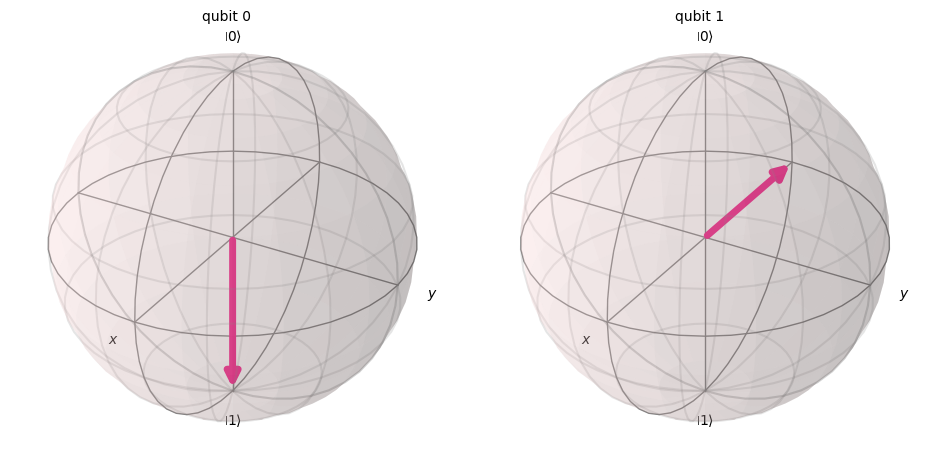

In [6]:
# Test oracle2 (balanced: f(0)=0, f(1)=1) and visualise the final state on the Bloch sphere.
# Expected: run_deutsch returns 'balanced'; q0 should point to the |1⟩ pole (south).
print("oracle2:", run_deutsch(oracle2))

# Reconstruct the full circuit to extract the statevector for visualisation
circ = qk.QuantumCircuit(2)
circ.x(1)                      # ancilla → |1⟩
circ.h([0, 1])                 # superposition
circ.append(oracle2, [0, 1])   # oracle2: CNOT (balanced)
circ.h(0)                      # final Hadamard on input qubit

sv = Statevector(circ)
plot_bloch_multivector(sv)     # q0 (left) should point south (|1⟩) for balanced

oracle4: constant


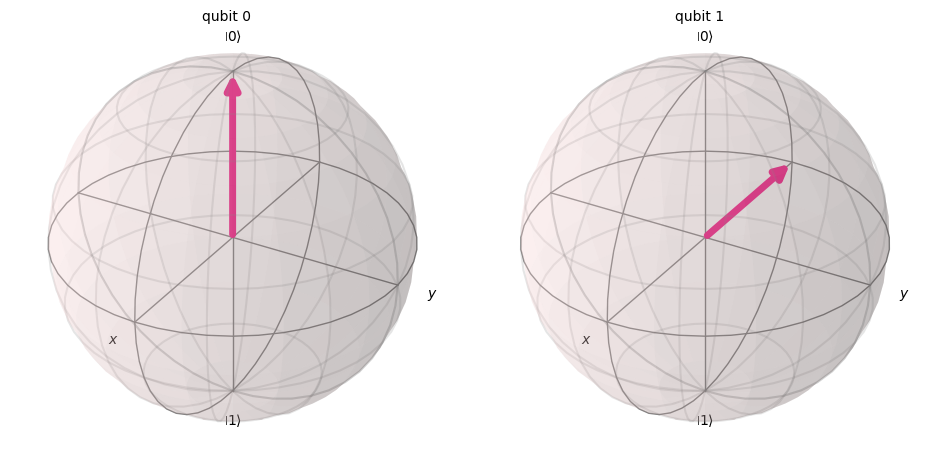

In [7]:
# Test oracle4 (constant: f(0)=f(1)=1) and visualise the final state on the Bloch sphere.
# Expected: run_deutsch returns 'constant'; q0 should point to the |0⟩ pole (north).
oracle4=qk.QuantumCircuit(2, name='oracle4')
print("oracle4:", run_deutsch(oracle4))

# Reconstruct the full circuit for statevector visualisation
circ = qk.QuantumCircuit(2)
circ.x(1)                      # ancilla → |1⟩
circ.h([0, 1])                 # superposition
circ.append(oracle4, [0, 1])   # oracle4: X on ancilla (constant f=1)
circ.h(0)                      # final Hadamard on input qubit

sv = Statevector(circ)
plot_bloch_multivector(sv)     # q0 (left) should point north (|0⟩) for constant

In [8]:
# Print a text circuit diagram for oracle1 (constant f=0) to show the full gate sequence.
# Note: the circuit includes 2 classical bits (for a measurement-ready layout),
# but measurement gates are not added here — the statevector approach is used instead.
circ = qk.QuantumCircuit(2, 2)   # 2 qubits, 2 classical bits (measurement registers)
circ.x(1)                         # ancilla → |1⟩
circ.h([0, 1])                    # superposition on both qubits
circ.append(oracle1, [0, 1])      # oracle1: identity (constant f=0)
circ.h(0)                         # final Hadamard on input qubit only
circ.draw('text')                  # display circuit as ASCII art

┌───┐     ┌──────────┐┌───┐
q_0: ┤ H ├─────┤0         ├┤ H ├
     ├───┤┌───┐│  oracle1 │└───┘
q_1: ┤ X ├┤ H ├┤1         ├─────
     └───┘└───┘└──────────┘     
c: 2/═══════════════════════════

In [9]:
# Run run_deutsch() on all 4 oracles and print the classification result.
# Expected: oracle1 → constant, oracle2 → balanced, oracle3 → balanced, oracle4 → constant
for oracle, label in [
    (oracle1, 'oracle1 (constant f=0)'),    # identity oracle
    (oracle2, 'oracle2 (balanced)'),         # CNOT oracle
    (oracle3, 'oracle3 (balanced)'),         # CNOT + X oracle
    (oracle4, 'oracle4 (constant f=1)'),    # X-on-ancilla oracle
]:
    result = run_deutsch(oracle)   # single oracle query determines constant vs balanced
    print(f"{label}: {result}")

oracle1 (constant f=0): constant
oracle2 (balanced): balanced
oracle3 (balanced): balanced
oracle4 (constant f=1): constant


In [10]:
# Final correctness assertions — ensure run_deutsch() matches theoretical expectations.
# Constant oracles must return 'constant'; balanced oracles must return 'balanced'.
assert run_deutsch(oracle1) == 'constant', "oracle1 should be constant"
assert run_deutsch(oracle2) == 'balanced', "oracle2 should be balanced"
assert run_deutsch(oracle3) == 'balanced', "oracle3 should be balanced"
assert run_deutsch(oracle4) == 'constant', "oracle4 should be constant"
print("All Deutsch algorithm tests passed!")

All Deutsch algorithm tests passed!


In [11]:
# Assert correctness
assert run_deutsch(oracle1) == 'constant'
assert run_deutsch(oracle2) == 'balanced'
assert run_deutsch(oracle3) == 'balanced'
assert run_deutsch(oracle4) == 'constant'
print("All Deutsch algorithm tests passed!")

All Deutsch algorithm tests passed!
